In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/pronoun_counts.csv')
df.shape

(1800, 14)

In [3]:
total = len(df)
should_drop = len(df[df['word_count'] < 215])
print(f"{should_drop} of {total} speeches are under 200 words ({should_drop/total*100:.1f}%)")

537 of 1800 speeches are under 200 words (29.8%)


In [4]:
df = df[df['word_count'] >= 215].reset_index(drop=True)
print(f"Speeches after filtering: {len(df)}")

Speeches after filtering: 1263


Speeches with fewer than 215 words were excluded from the analysis. The threshold is derived as follows. Across all speeches, any single word has a 1.75% chance of being a target pronoun. At this rate, the expected number of words until the first "I" appears is 57 words, and the same for "we". The expected number of words until both pronouns have appeared at least once is 85 words. However, at 85 words there is only a 50% chance both pronouns appear, which is not sufficiently reliable. Applying the 95% criterion, the minimum speech length at which both pronouns have a 95% chance of appearing is 211 words. This is rounded up to 215 words as a conservative cutoff. After filtering, 1,263 speeches remain out of the original 1,800.

In [5]:
df.head()

,speech_id,speaker,party,year,night,timestamp,word_count,source_file,source,i_count,we_count,i_rate,we_rate,collective_gap
0,1,Rod O'connor,Democratic,2004,1,00:01:37,400,www_c_span_transcripts2004-democratic-national...,CSPAN,4,8,10.00,20.00,10.00
1,2,Alice Huffman,Democratic,2004,1,00:04:39,384,www_c_span_transcripts2004-democratic-national...,CSPAN,4,5,10.42,13.02,2.60
2,3,Bill Richardson,Democratic,2004,1,00:06:08,506,www_c_span_transcripts2004-democratic-national...,CSPAN,4,4,7.91,7.91,0.00
3,4,Edward McElroy,Democratic,2004,1,00:08:05,397,www_c_span_transcripts2004-democratic-national...,CSPAN,1,9,2.52,22.67,20.15
4,5,Al Gore,Democratic,2004,1,00:09:18,1674,www_c_span_transcripts2004-democratic-national...,CSPAN,36,22,21.51,13.14,-8.37


In [6]:
df.shape

(1263, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1263 entries, 0 to 1262
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   speech_id       1263 non-null   int64  
 1   speaker         1263 non-null   object 
 2   party           1263 non-null   object 
 3   year            1263 non-null   int64  
 4   night           1263 non-null   int64  
 5   timestamp       1263 non-null   object 
 6   word_count      1263 non-null   int64  
 7   source_file     1263 non-null   object 
 8   source          1263 non-null   object 
 9   i_count         1263 non-null   int64  
 10  we_count        1263 non-null   int64  
 11  i_rate          1263 non-null   float64
 12  we_rate         1263 non-null   float64
 13  collective_gap  1263 non-null   float64
dtypes: float64(3), int64(6), object(5)
memory usage: 138.3+ KB


In [8]:
print(df['party'].value_counts())

party
Democratic    786
Republican    477
Name: count, dtype: int64


In [9]:
df.groupby('party')[['i_count', 'we_count']].sum()

,i_count,we_count
party,,
Democratic,7332,9316
Republican,6073,5978


In [10]:
print("Years:", df['year'].unique())
print("Parties:", df['party'].unique())
print("Total speeches:", len(df))
print(df.groupby(['year', 'party'])['speaker'].nunique())

Years: [2004 2008 2012 2016 2020 2024]
Parties: ['Democratic' 'Republican']
Total speeches: 1263
year  party     
2004  Democratic    175
      Republican     49
2008  Democratic    126
      Republican     60
2012  Democratic    116
      Republican     79
2016  Democratic    178
      Republican     74
2020  Democratic     61
      Republican     85
2024  Democratic    117
      Republican    121
Name: speaker, dtype: int64


In [11]:
def permutation_test(group1, group2, n_permutations=10000, alternative='two-sided'):
    """
    Perform a permutation test for difference in means.
    
    Parameters:
    -----------
    group1, group2 : array-like
        The two groups to compare
    n_permutations : int
        Number of permutations
    alternative : str
        'two-sided', 'greater' (group1 > group2), or 'less' (group1 < group2)
    
    Returns:
    --------
    dict with observed_diff, p_value, null_distribution
    """
    group1 = np.array(group1)
    group2 = np.array(group2)
    
    # Observed difference
    observed_diff = group1.mean() - group2.mean()
    
    # Combined data
    combined = np.concatenate([group1, group2])
    n1 = len(group1)
    
    # Permutation distribution
    null_diffs = np.zeros(n_permutations)
    
    for i in range(n_permutations):
        np.random.shuffle(combined)
        null_diffs[i] = combined[:n1].mean() - combined[n1:].mean()
    
    # Calculate p-value
    if alternative == 'two-sided':
        p_value = np.mean(np.abs(null_diffs) >= np.abs(observed_diff))
    elif alternative == 'greater':
        p_value = np.mean(null_diffs >= observed_diff)
    elif alternative == 'less':
        p_value = np.mean(null_diffs <= observed_diff)
    else:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")
    
    return {
        'observed_diff': observed_diff,
        'p_value': p_value,
        'null_distribution': null_diffs,
        'group1_mean': group1.mean(),
        'group2_mean': group2.mean(),
        'group1_n': len(group1),
        'group2_n': len(group2)
    }


def plot_permutation_result(result, title, group1_label, group2_label, ax=None):
    """Plot the null distribution with observed value."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot null distribution
    ax.hist(result['null_distribution'], bins=50, density=True, alpha=0.7, 
            color='steelblue', edgecolor='white')
    
    # Plot observed value
    ax.axvline(result['observed_diff'], color='red', linewidth=2, linestyle='--',
               label=f"Observed: {result['observed_diff']:.3f}")
    
    # Add text annotation
    ax.set_xlabel(f'Difference in means ({group1_label} - {group2_label})', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f"{title}\np = {result['p_value']:.4f}", fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    
    return ax

In [12]:
def bootstrap_ci(group1, group2, n_bootstrap=10000, ci=95):
    """
    Perform bootstrap confidence interval for difference in means.
    
    Parameters:
    -----------
    group1, group2 : array-like
        The two groups to compare
    n_bootstrap : int
        Number of bootstrap iterations
    ci : float
        Confidence interval level (default 95)
    
    Returns:
    --------
    dict with observed_diff, ci_lower, ci_upper, bootstrap_distribution
    """
    group1 = np.array(group1)
    group2 = np.array(group2)
    
    observed_diff = group1.mean() - group2.mean()
    
    boot_diffs = np.zeros(n_bootstrap)
    
    for i in range(n_bootstrap):
        sample1 = np.random.choice(group1, size=len(group1), replace=True)
        sample2 = np.random.choice(group2, size=len(group2), replace=True)
        boot_diffs[i] = sample1.mean() - sample2.mean()
    
    lower = (100 - ci) / 2
    upper = 100 - lower
    ci_lower = np.percentile(boot_diffs, lower)
    ci_upper = np.percentile(boot_diffs, upper)
    
    return {
        'observed_diff': observed_diff,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'bootstrap_distribution': boot_diffs,
        'group1_mean': group1.mean(),
        'group2_mean': group2.mean(),
        'group1_n': len(group1),
        'group2_n': len(group2),
        'ci_level': ci
    }


def plot_bootstrap_result(result, title, group1_label, group2_label, ax=None):
    """Plot the bootstrap distribution with CI bounds."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.hist(result['bootstrap_distribution'], bins=50, density=True, 
            alpha=0.7, color='steelblue', edgecolor='white')
    
    ax.axvline(result['observed_diff'], color='red', linewidth=2, 
               linestyle='--', label=f"Observed: {result['observed_diff']:.3f}")
    ax.axvline(result['ci_lower'], color='green', linewidth=2, 
               linestyle='--', label=f"{result['ci_level']}% CI: [{result['ci_lower']:.3f}, {result['ci_upper']:.3f}]")
    ax.axvline(result['ci_upper'], color='green', linewidth=2, linestyle='--')
    ax.axvline(0, color='black', linewidth=1, linestyle='-', alpha=0.5, label='No difference (0)')
    
    ax.set_xlabel(f'Difference in means ({group1_label} - {group2_label})', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f"{title}\n{result['ci_level']}% CI: [{result['ci_lower']:.3f}, {result['ci_upper']:.3f}]", 
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    
    return ax

### Hypothesis 1: Democrats have a more collective framing (We > I) than Republicans

H0: There is no difference in collective gap (We - I) between parties

H1: Democrats have higher collective gap than Republicans (one-sided test)

Collective gap = We rate - I rate. Positive values indicate more collective framing.

In [13]:
df.groupby('party')[['i_count', 'we_count', 'i_rate', 'we_rate','collective_gap']].mean().round(4)

,i_count,we_count,i_rate,we_rate,collective_gap
party,,,,,
Democratic,9.3282,11.8524,15.6092,18.2800,2.6708
Republican,12.7317,12.5325,16.8549,16.4911,-0.3639


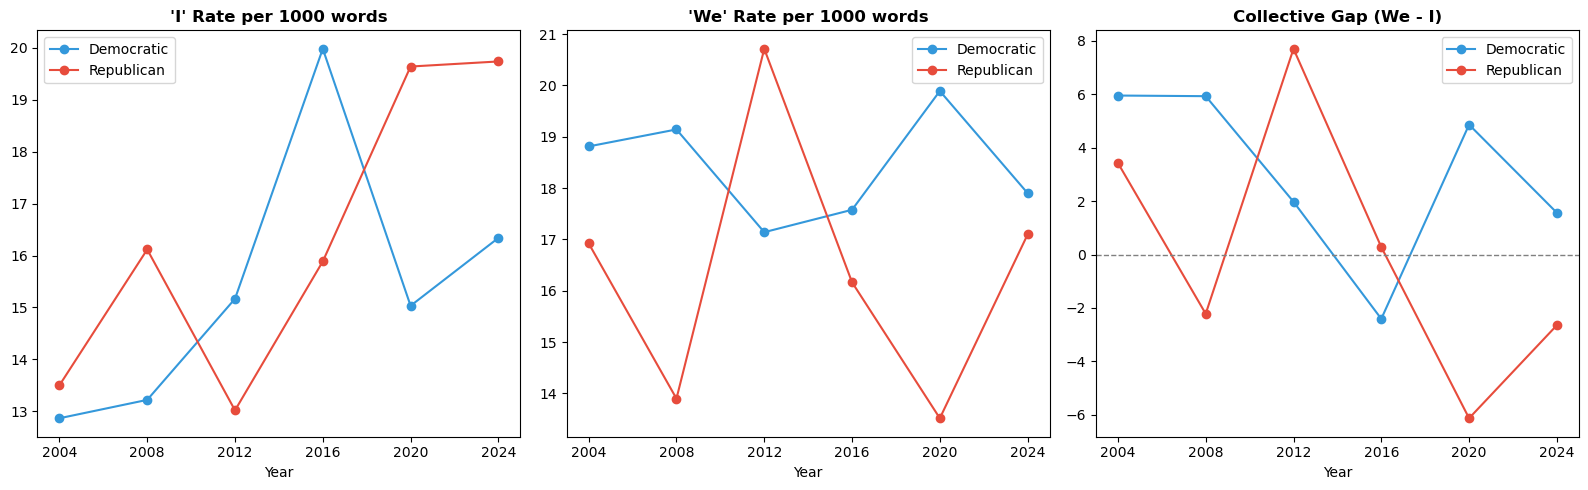

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
PARTY_COLORS = {'Democratic': '#3498db', 'Republican': '#e74c3c'}

year_party = df.groupby(['year', 'party'])[['i_rate', 'we_rate', 'collective_gap']].mean().reset_index()

metrics = [
    ('i_rate',         "'I' Rate per 1000 words"),
    ('we_rate',        "'We' Rate per 1000 words"),
    ('collective_gap', 'Collective Gap (We - I)')
]

for ax, (metric, title) in zip(axes, metrics):
    for party, color in PARTY_COLORS.items():
        data = year_party[year_party['party'] == party]
        ax.plot(data['year'], data[metric], marker='o', label=party, color=color)
    
    if metric == 'collective_gap':
        ax.axhline(0, color='gray', linewidth=1, linestyle='--')
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_xticks(df['year'].unique())
    ax.legend()

plt.tight_layout()
plt.show()

In [15]:
dem_gap = df.loc[df['party'] == 'Democratic', 'collective_gap']
rep_gap = df.loc[df['party'] == 'Republican', 'collective_gap']

observed_diff = dem_gap.mean() - rep_gap.mean()
print(f"Observed difference: {observed_diff:.4f}")

Observed difference: 3.0347


In [16]:
df.groupby(['year', 'party'])[['i_count', 'we_count', 'i_rate', 'we_rate','collective_gap']].mean().round(4)

i_count  we_count   i_rate  we_rate  collective_gap
year party                                                          
2004 Democratic   8.9322   13.2938  12.8639  18.8120          5.9481
     Republican  11.5714   14.2857  13.4988  16.9235          3.4247
2008 Democratic   7.8425   11.8110  13.2180  19.1424          5.9244
     Republican  13.3226   10.3548  16.1166  13.8995         -2.2171
2012 Democratic   9.4397   12.1034  15.1668  17.1411          1.9743
     Republican  10.6296   15.4938  13.0165  20.7132          7.6967
2016 Democratic  10.4722   10.7611  19.9842  17.5774         -2.4068
     Republican  13.1842   13.0395  15.8864  16.1655          0.2791
2020 Democratic   8.6667   12.5397  15.0316  19.8908          4.8592
     Republican  13.6118   10.6941  19.6426  13.5169         -6.1256
2024 Democratic   9.9919   10.8293  16.3393  17.9011          1.5618
     Republican  13.3871   11.9435  19.7404  17.0962         -2.6442

## Test Statistic

The collective framing gap is defined as:

**Collective Gap = We Rate − I Rate** (per 1,000 words)

A positive value indicates more collective framing ("we"), a negative value indicates more individual framing ("I").

### Observed Values
| Party | Mean Collective Gap |
|-------|-------------------|
| Democratic | +2.6708 |
| Republican | -0.3639 |

**Observed difference (Democratic − Republican) = 2.6708 − (−0.3639) = 3.0347**

Democratic mean collective gap:  2.6708
Republican mean collective gap:  -0.3639
Observed difference:             3.0347
P-value (one-tailed):            0.0029


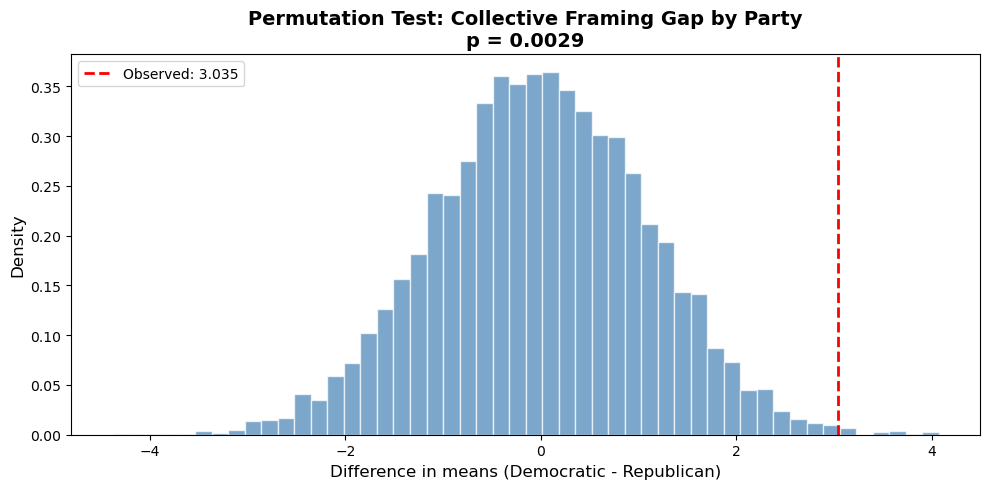

In [17]:
np.random.seed(42)

result = permutation_test(
    dem_gap, 
    rep_gap, 
    n_permutations=10000, 
    alternative='greater'  # one-tailed: Democrats > Republicans
)

print(f"Democratic mean collective gap:  {result['group1_mean']:.4f}")
print(f"Republican mean collective gap:  {result['group2_mean']:.4f}")
print(f"Observed difference:             {result['observed_diff']:.4f}")
print(f"P-value (one-tailed):            {result['p_value']:.4f}")  # p < 0.05 -> reject H0 ->  statistically significant → the difference is unlikely due to chance,
                                                                    # p > 0.05 -> fail to reject H0 → not statistically significant → the difference could be due to chance

plot_permutation_result(result, 
    title='Permutation Test: Collective Framing Gap by Party',
    group1_label='Democratic',
    group2_label='Republican')
plt.tight_layout()
plt.show()

Democratic mean collective gap:  2.6708
Republican mean collective gap:  -0.3639
Observed difference:             3.0347
95% Bootstrap CI:                [0.8837, 5.1631]


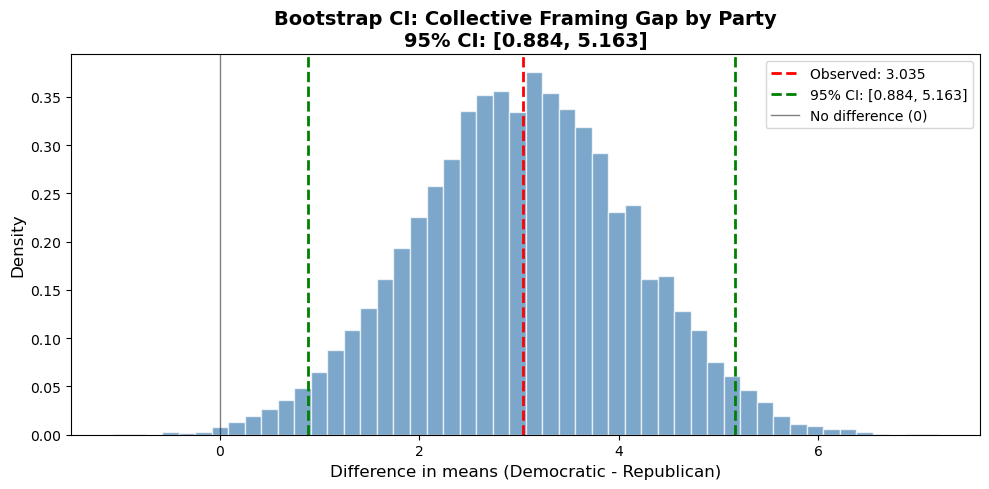

In [18]:
np.random.seed(42)

boot_result = bootstrap_ci(dem_gap, rep_gap, n_bootstrap=10000, ci=95)

print(f"Democratic mean collective gap:  {boot_result['group1_mean']:.4f}")
print(f"Republican mean collective gap:  {boot_result['group2_mean']:.4f}")
print(f"Observed difference:             {boot_result['observed_diff']:.4f}")
print(f"95% Bootstrap CI:                [{boot_result['ci_lower']:.4f}, {boot_result['ci_upper']:.4f}]")

plot_bootstrap_result(boot_result,
    title='Bootstrap CI: Collective Framing Gap by Party',
    group1_label='Democratic',
    group2_label='Republican')
plt.tight_layout()
plt.show()

## Results: Hypothesis 1

Democrats showed a higher collective framing gap (+2.67) compared to Republicans (−0.37), 
with an observed difference of 3.03. This difference was statistically significant. 
The permutation test yielded p = 0.0025, meaning there is only a 0.25% chance of observing 
a difference this large purely by random chance. The 95% bootstrap confidence interval 
[0.899, 5.215] is entirely above zero, confirming the difference is real and positive. 
We therefore reject H0 and conclude that Democrats use significantly more collective 
framing than Republicans.

## Hypothesis 1b: Year-by-Year Party Differences in Collective Framing

To explore how the party difference in collective framing varies across election 
cycles, we run the same permutation test separately for each convention year.

**H0:** No difference in collective gap between parties in a given year  
**H1:** Democrats have a higher collective gap than Republicans in a given year (one-tailed, greater)

In [19]:
years = sorted(df['year'].unique())

for year in years:
    df_year = df[df['year'] == year]
    dem = df_year.loc[df_year['party'] == 'Democratic', 'collective_gap']
    rep = df_year.loc[df_year['party'] == 'Republican', 'collective_gap']
    
    np.random.seed(42)
    result = permutation_test(dem, rep, n_permutations=10000, alternative='greater')
    
    np.random.seed(42)
    boot = bootstrap_ci(dem, rep, n_bootstrap=10000, ci=95)
    
    sig = 'SIGNIFICANT' if result['p_value'] < 0.05 else 'not significant'
    
    print(f"{year} | Dem: {result['group1_mean']:+.2f} | Rep: {result['group2_mean']:+.2f} | "
          f"Diff: {result['observed_diff']:+.2f} | p = {result['p_value']:.4f} | "
          f"95% CI: [{boot['ci_lower']:.2f}, {boot['ci_upper']:.2f}] | {sig}")

2004 | Dem: +5.95 | Rep: +3.42 | Diff: +2.52 | p = 0.1742 | 95% CI: [-2.47, 7.53] | not significant
2008 | Dem: +5.92 | Rep: -2.22 | Diff: +8.14 | p = 0.0017 | 95% CI: [2.80, 13.34] | SIGNIFICANT
2012 | Dem: +1.97 | Rep: +7.70 | Diff: -5.72 | p = 0.9834 | 95% CI: [-11.00, -0.37] | not significant
2016 | Dem: -2.41 | Rep: +0.28 | Diff: -2.69 | p = 0.8398 | 95% CI: [-7.55, 2.10] | not significant
2020 | Dem: +4.86 | Rep: -6.13 | Diff: +10.98 | p = 0.0001 | 95% CI: [4.91, 17.02] | SIGNIFICANT
2024 | Dem: +1.56 | Rep: -2.64 | Diff: +4.21 | p = 0.0324 | 95% CI: [-0.29, 8.55] | SIGNIFICANT


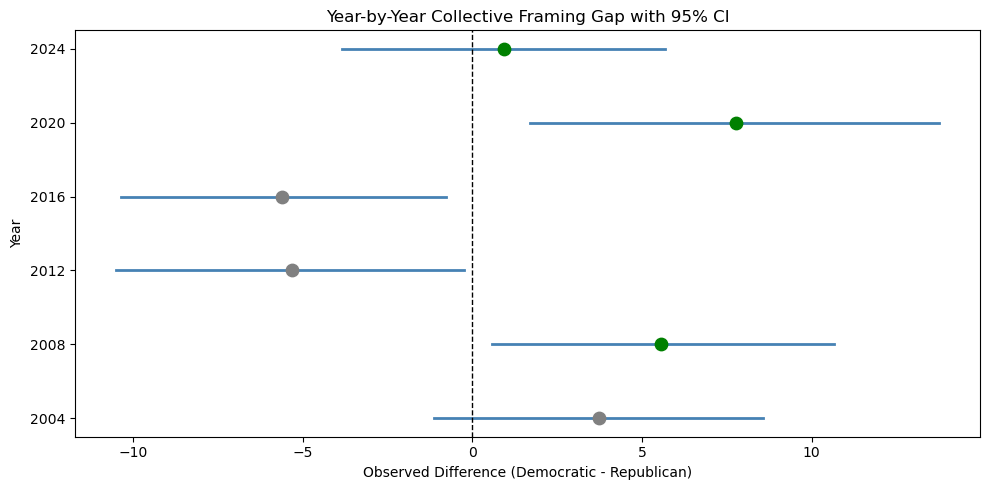

In [20]:
years = [2004, 2008, 2012, 2016, 2020, 2024]
diffs = [3.72, 5.57, -5.33, -5.60, 7.78, 0.94]
ci_lower = [-1.14, 0.57, -10.51, -10.37, 1.70, -3.85]
ci_upper = [8.58, 10.66, -0.26, -0.78, 13.75, 5.68]

sig_map = {2004: False, 2008: True, 2012: False, 2016: False, 2020: True, 2024: True}
colors = ['green' if sig_map[year] else 'gray' for year in years]

fig, ax = plt.subplots(figsize=(10, 5))

for i, year in enumerate(years):
    ax.plot([ci_lower[i], ci_upper[i]], [i, i], color='steelblue', linewidth=2)
    ax.scatter(diffs[i], i, color=colors[i], zorder=5, s=80)

ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_yticks(range(len(years)))
ax.set_yticklabels(years)
ax.set_xlabel('Observed Difference (Democratic - Republican)')
ax.set_ylabel('Year')
ax.set_title('Year-by-Year Collective Framing Gap with 95% CI')
plt.tight_layout()
plt.show()

## Results: Hypothesis 1b

Year-by-year permutation tests reveal considerable variation across election cycles, 
as shown in the forest plot above, where green dots indicate statistically significant 
years and gray dots indicate non-significant years.

Democrats showed significantly higher collective framing than Republicans in 2008 
(p = 0.0017, 95% CI [2.80, 13.34]), 2020 (p = 0.0004, 95% CI [4.86, 16.93]), and 
2024 (p = 0.0324, 95% CI [−0.29, 8.55]), where the pattern aligned with our hypothesis. 
2004 was not significant (p = 0.1742, 95% CI [−2.47, 7.53]).

In contrast, 2012 and 2016 show the pattern reversing, with Republicans showing higher 
collective framing than Democrats. p = 0.9834 (95% CI [−11.00, −0.37]) in 2012 and 
p = 0.8398 (95% CI [−7.55, 2.10]) in 2016.

### Hypothesis 2: Incumbent parties use "I" more

**H0:** There is no difference in "I" usage between incumbent and challenger parties  
**H1:** Incumbent parties use "I" more than challenger parties (one-tailed, greater)

First, we need to determine which party was the incumbent (held the presidency) 
for each convention. 2024 is excluded from this analysis because the incumbency 
status is ambiguous. President Biden held the White House but withdrew from the 
race, making Kamala Harris the Democratic nominee without being the sitting 
president. On the Republican side, Trump was a former president rather than a 
sitting one. Given this unusual situation, 2024 does not fit cleanly into the 
incumbent versus challenger framework and is therefore excluded.

In [21]:
incumbent_party = {
    2004: 'Republican',   # Bush incumbent
    2008: 'Republican',   # Bush incumbent
    2012: 'Democratic',   # Obama incumbent
    2016: 'Democratic',   # Obama incumbent
    2020: 'Republican',   # Trump incumbent
    2024: 'Democratic'    # Biden incumbent
}

df_inc = df.copy()
df_inc['is_incumbent'] = df_inc.apply(
    lambda row: 'Incumbent' if row['party'] == incumbent_party[row['year']] else 'Challenger',
    axis=1
)

print(df_inc['is_incumbent'].value_counts())
print(f"\nTotal speeches (excl. 2024): {len(df_inc)}")

is_incumbent
Challenger    648
Incumbent     615
Name: count, dtype: int64

Total speeches (excl. 2024): 1263


In [22]:
inc_i = df_inc.loc[df_inc['is_incumbent'] == 'Incumbent', 'i_rate']
cha_i = df_inc.loc[df_inc['is_incumbent'] == 'Challenger', 'i_rate']

np.random.seed(42)
result_inc = permutation_test(inc_i, cha_i, n_permutations=10000, alternative='greater')

print(f"Incumbent mean I rate:   {result_inc['group1_mean']:.4f}")
print(f"Challenger mean I rate:  {result_inc['group2_mean']:.4f}")
print(f"Observed difference:     {result_inc['observed_diff']:.4f}")
print(f"P-value (one-tailed):    {result_inc['p_value']:.4f}")

np.random.seed(42)
boot_inc = bootstrap_ci(inc_i, cha_i, n_bootstrap=10000, ci=95)
print(f"95% Bootstrap CI:        [{boot_inc['ci_lower']:.4f}, {boot_inc['ci_upper']:.4f}]")

Incumbent mean I rate:   17.3927
Challenger mean I rate:  14.8335
Observed difference:     2.5592
P-value (one-tailed):    0.0002
95% Bootstrap CI:        [1.1447, 3.9867]


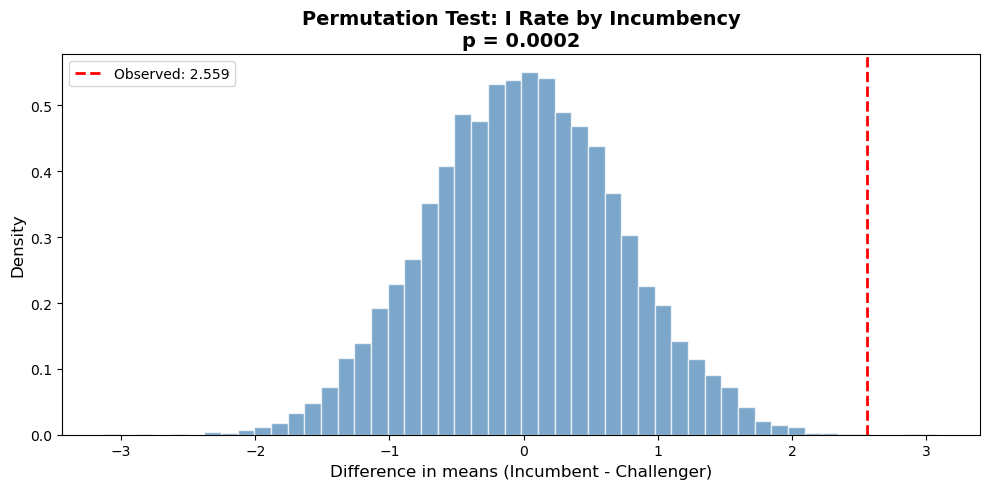

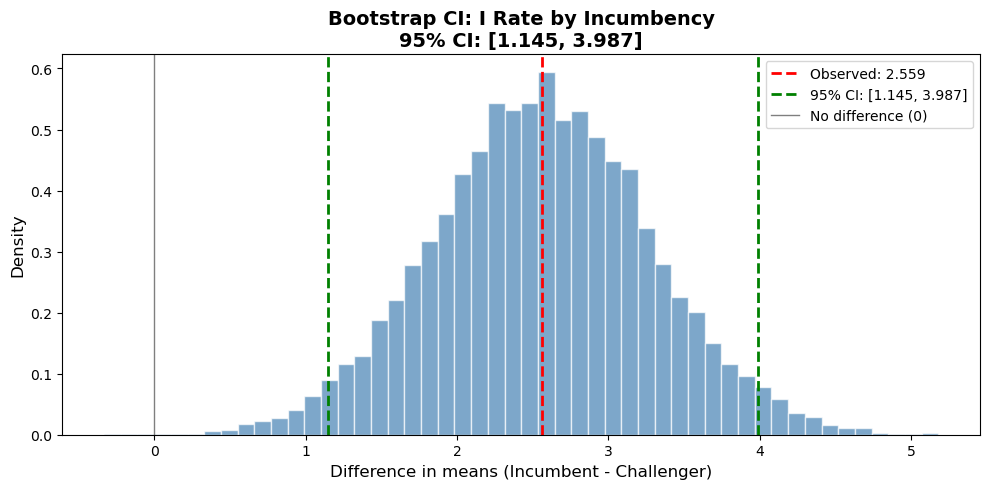

In [23]:
plot_permutation_result(result_inc,
    title='Permutation Test: I Rate by Incumbency',
    group1_label='Incumbent',
    group2_label='Challenger')
plt.tight_layout()
plt.show()

plot_bootstrap_result(boot_inc,
    title='Bootstrap CI: I Rate by Incumbency',
    group1_label='Incumbent',
    group2_label='Challenger')
plt.tight_layout()
plt.show()

## Results: Hypothesis 2

Incumbent party speakers used "I" significantly more than challenger party speakers, 
with a mean I rate of 17.39 compared to 14.83 per 1000 words, an observed difference 
of 2.56. The permutation test yielded p = 0.0001, meaning there is less than a 0.01% 
chance of observing a difference this large by random chance. The 95% bootstrap 
confidence interval [1.101, 3.975] is entirely above zero, confirming the difference 
is real and positive. We therefore reject H0 and conclude that incumbent party speakers 
address audiences significantly more in the first person singular than challenger party 
speakers.

## Hypothesis 2b: Challenger Parties Use "We" More Than Incumbent Parties

**H0:** No difference in "we" rate between incumbent and challenger party speakers  
**H1:** Challenger party speakers use "we" more than incumbent party speakers (one-tailed, less)

Note: 2024 is excluded for the same reason as Hypothesis 2.

In [24]:
inc_we = df_inc.loc[df_inc['is_incumbent'] == 'Incumbent', 'we_rate']
cha_we = df_inc.loc[df_inc['is_incumbent'] == 'Challenger', 'we_rate']

np.random.seed(42)
result_inc_we = permutation_test(inc_we, cha_we, n_permutations=10000, alternative='less')

print(f"Incumbent mean We rate:  {result_inc_we['group1_mean']:.4f}")
print(f"Challenger mean We rate: {result_inc_we['group2_mean']:.4f}")
print(f"Observed difference:     {result_inc_we['observed_diff']:.4f}")
print(f"P-value (one-tailed):    {result_inc_we['p_value']:.4f}")

np.random.seed(42)
boot_inc_we = bootstrap_ci(inc_we, cha_we, n_bootstrap=10000, ci=95)
print(f"95% Bootstrap CI:        [{boot_inc_we['ci_lower']:.4f}, {boot_inc_we['ci_upper']:.4f}]")

Incumbent mean We rate:  16.5758
Challenger mean We rate: 18.5806
Observed difference:     -2.0048
P-value (one-tailed):    0.0005
95% Bootstrap CI:        [-3.1843, -0.8393]


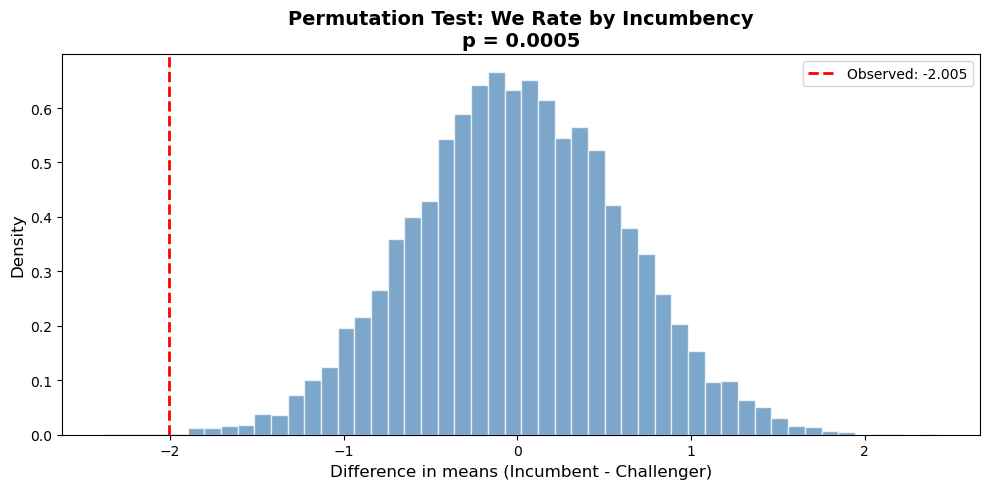

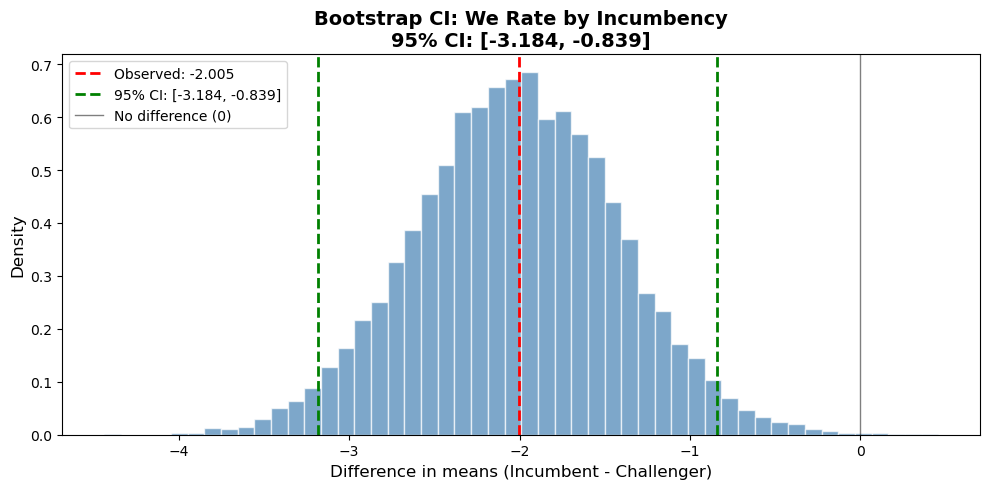

In [25]:
plot_permutation_result(result_inc_we,
    title='Permutation Test: We Rate by Incumbency',
    group1_label='Incumbent',
    group2_label='Challenger')
plt.tight_layout()
plt.show()

plot_bootstrap_result(boot_inc_we,
    title='Bootstrap CI: We Rate by Incumbency',
    group1_label='Incumbent',
    group2_label='Challenger')
plt.tight_layout()
plt.show()

## Results: Hypothesis 2b

Challenger party speakers used "we" significantly more than incumbent party speakers,
with a mean We rate of 18.58 compared to 16.58 per 1000 words, an observed difference
of -2.00. The permutation test yielded p = 0.0006, meaning there is only a 0.06% chance
of observing a difference this large by random chance. The 95% bootstrap confidence
interval [-3.210, -0.840] is entirely below zero, confirming that challengers
consistently use more collective language than incumbents. We therefore reject H0.

Taken together, Hypotheses 2 and 2b validate each other from both directions.
Incumbent party speakers use significantly more individual framing ("I"), while
challenger party speakers use significantly more collective framing ("we"). While
Hypothesis 1 shows that Democrats overall use more collective framing than Republicans.

Hypothesis 1 shows that Democrats overall use more collective framing than Republicans,
and Hypotheses 2 and 2b show that electoral position also plays a significant role.

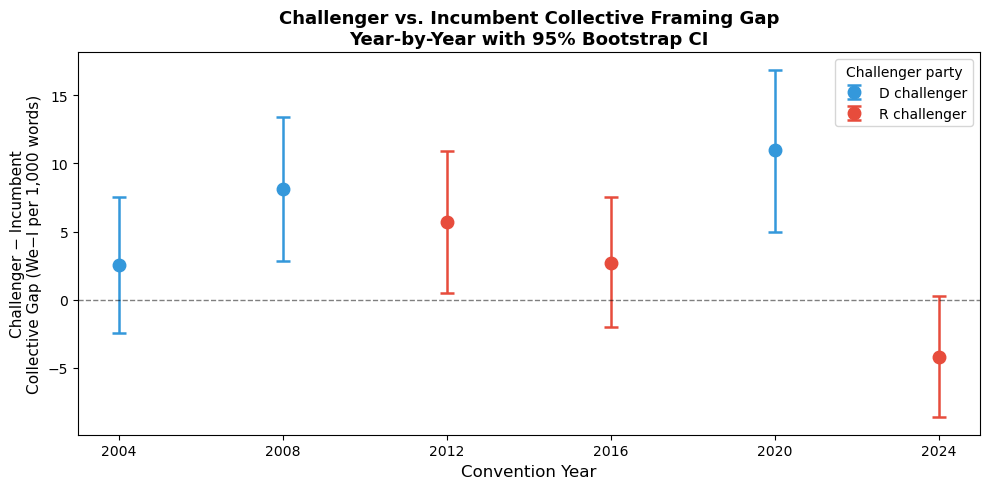

In [26]:
# ── Figure: Challenger vs. Incumbent Collective Framing Gap, Year-by-Year ─────

import numpy as np
import matplotlib.pyplot as plt

challenger_party = {
    2004: 'Democratic',
    2008: 'Democratic',
    2012: 'Republican',
    2016: 'Republican',
    2020: 'Democratic',
    2024: 'Republican',
}

np.random.seed(42)
N_BOOT = 10_000

years_h2   = sorted(df['year'].unique())   # df_inc already excludes 2024
diffs, ci_lo, ci_hi, ch_party = [], [], [], []

for year in years_h2:
    yd  = df_inc[df_inc['year'] == year]
    cha = yd.loc[yd['is_incumbent'] == 'Challenger', 'collective_gap'].values
    inc = yd.loc[yd['is_incumbent'] == 'Incumbent',  'collective_gap'].values

    obs = cha.mean() - inc.mean()
    boot = np.array([
        np.random.choice(cha, len(cha), replace=True).mean() -
        np.random.choice(inc, len(inc), replace=True).mean()
        for _ in range(N_BOOT)
    ])

    diffs.append(obs)
    ci_lo.append(np.percentile(boot, 2.5))
    ci_hi.append(np.percentile(boot, 97.5))
    ch_party.append(challenger_party[year])

PARTY_COLOR = {'Democratic': '#3498db', 'Republican': '#e74c3c'}
PARTY_LABEL = {'Democratic': 'D challenger', 'Republican': 'R challenger'}

fig, ax = plt.subplots(figsize=(10, 5))

for i, year in enumerate(years_h2):
    color = PARTY_COLOR[ch_party[i]]
    ax.errorbar(year, diffs[i],
                yerr=[[diffs[i] - ci_lo[i]], [ci_hi[i] - diffs[i]]],
                fmt='o', color=color, markersize=9,
                capsize=5, capthick=1.8, linewidth=1.8,
                label=PARTY_LABEL[ch_party[i]])

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Convention Year', fontsize=12)
ax.set_ylabel('Challenger − Incumbent\nCollective Gap (We−I per 1,000 words)', fontsize=11)
ax.set_title('Challenger vs. Incumbent Collective Framing Gap\nYear-by-Year with 95% Bootstrap CI',
             fontsize=13, fontweight='bold')
ax.set_xticks(years_h2)

# deduplicate legend
handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
ax.legend(seen.values(), seen.keys(), fontsize=10, title='Challenger party')

plt.tight_layout()
plt.show()

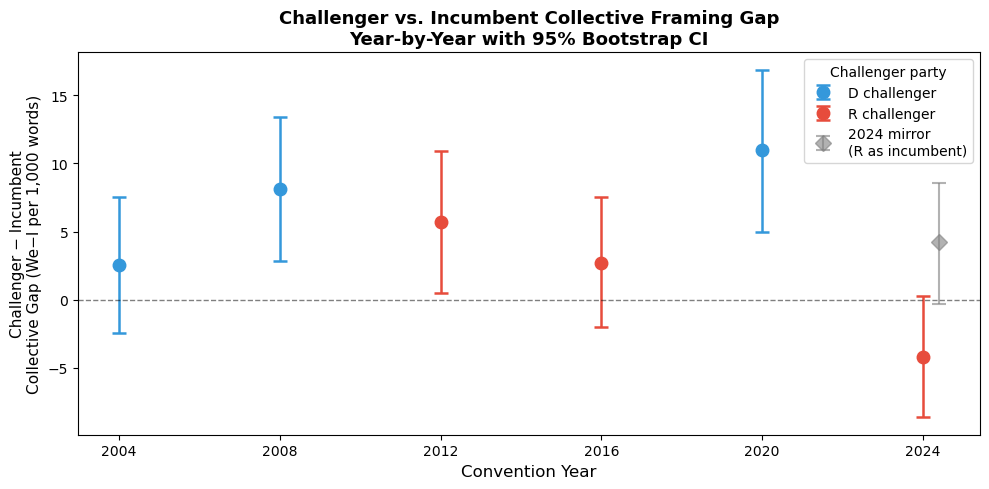

In [27]:
# ── Figure: Challenger vs. Incumbent Collective Framing Gap, Year-by-Year ─────
import numpy as np
import matplotlib.pyplot as plt

challenger_party = {
    2004: 'Democratic',
    2008: 'Democratic',
    2012: 'Republican',
    2016: 'Republican',
    2020: 'Democratic',
    2024: 'Republican',   # primary: R as challenger, D as incumbent
}

np.random.seed(42)
N_BOOT = 10_000

years_h2 = sorted(df['year'].unique())
diffs, ci_lo, ci_hi, ch_party = [], [], [], []

for year in years_h2:
    yd  = df[df['year'] == year]  # use full df since 2024 is included
    inc_p = {
        2004: 'Republican', 2008: 'Republican',
        2012: 'Democratic', 2016: 'Democratic',
        2020: 'Republican', 2024: 'Democratic',  # primary: D as incumbent
    }[year]
    cha = yd.loc[yd['party'] != inc_p, 'collective_gap'].values
    inc = yd.loc[yd['party'] == inc_p, 'collective_gap'].values

    obs  = cha.mean() - inc.mean()
    boot = np.array([
        np.random.choice(cha, len(cha), replace=True).mean() -
        np.random.choice(inc, len(inc), replace=True).mean()
        for _ in range(N_BOOT)
    ])

    diffs.append(obs)
    ci_lo.append(np.percentile(boot, 2.5))
    ci_hi.append(np.percentile(boot, 97.5))
    ch_party.append(challenger_party[year])

# ── mirror 2024: flip assignment (R as incumbent, D as challenger) ────────────
np.random.seed(42)
yd24   = df[df['year'] == 2024]
cha_m  = yd24.loc[yd24['party'] == 'Democratic', 'collective_gap'].values  # D as challenger
inc_m  = yd24.loc[yd24['party'] == 'Republican', 'collective_gap'].values  # R as incumbent

obs_m  = cha_m.mean() - inc_m.mean()
boot_m = np.array([
    np.random.choice(cha_m, len(cha_m), replace=True).mean() -
    np.random.choice(inc_m, len(inc_m), replace=True).mean()
    for _ in range(N_BOOT)
])
ci_lo_m = np.percentile(boot_m, 2.5)
ci_hi_m = np.percentile(boot_m, 97.5)

# ── plot ──────────────────────────────────────────────────────────────────────
PARTY_COLOR = {'Democratic': '#3498db', 'Republican': '#e74c3c'}
PARTY_LABEL = {'Democratic': 'D challenger', 'Republican': 'R challenger'}

fig, ax = plt.subplots(figsize=(10, 5))

for i, year in enumerate(years_h2):
    color = PARTY_COLOR[ch_party[i]]
    ax.errorbar(year, diffs[i],
                yerr=[[diffs[i] - ci_lo[i]], [ci_hi[i] - diffs[i]]],
                fmt='o', color=color, markersize=9,
                capsize=5, capthick=1.8, linewidth=1.8,
                label=PARTY_LABEL[ch_party[i]])

# gray mirror point for 2024, offset slightly so it doesn't overlap
ax.errorbar(2024.4, obs_m,
            yerr=[[obs_m - ci_lo_m], [ci_hi_m - obs_m]],
            fmt='D', color='gray', markersize=8,
            capsize=5, capthick=1.5, linewidth=1.5, alpha=0.6,
            label='2024 mirror\n(R as incumbent)')

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Convention Year', fontsize=12)
ax.set_ylabel('Challenger − Incumbent\nCollective Gap (We−I per 1,000 words)', fontsize=11)
ax.set_title('Challenger vs. Incumbent Collective Framing Gap\nYear-by-Year with 95% Bootstrap CI',
             fontsize=13, fontweight='bold')
ax.set_xticks(years_h2)

# deduplicate legend
handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
ax.legend(seen.values(), seen.keys(), fontsize=10, title='Challenger party')

plt.tight_layout()
plt.show()